In [239]:
import pandas as pd

In [240]:
#Load dataset
df = pd.read_csv("turkish_dramas_publishable.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3050 entries, 0 to 3049
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             3050 non-null   object 
 1   rating            2023 non-null   float64
 2   genres            2953 non-null   object 
 3   votes             2023 non-null   object 
 4   synopsis          1767 non-null   object 
 5   actors/actresses  3050 non-null   object 
 6   startYear         2953 non-null   object 
 7   endYear           2953 non-null   object 
 8   writer            3050 non-null   object 
 9   director          3050 non-null   object 
 10  id                3050 non-null   object 
 11  runtimeMinutes    2953 non-null   object 
 12  image_url         2602 non-null   object 
dtypes: float64(1), object(12)
memory usage: 309.9+ KB


In [241]:
#Check missing values
df.isnull().sum()

,0
title,0
rating,1027
genres,97
votes,1027
synopsis,1283
actors/actresses,0
startYear,97
endYear,97
writer,0
director,0


In [242]:
# Converting votes to numeric form rather than string from
df['votes'] = df['votes'].str.replace('K', '000')
df['votes'] = df['votes'].str.replace('.', '')
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

In [243]:
# Remove rows with missing values in key variable (rating and votes)
df=df.dropna(subset=['rating','votes'])

In [244]:
#Removing rows with missing values in genres, start year and runtime minutes
df = df.dropna(subset= ['genres', 'startYear', 'runtimeMinutes'])


In [245]:
#Checkpoint
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1993 entries, 0 to 2686
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             1993 non-null   object 
 1   rating            1993 non-null   float64
 2   genres            1993 non-null   object 
 3   votes             1993 non-null   float64
 4   synopsis          1484 non-null   object 
 5   actors/actresses  1993 non-null   object 
 6   startYear         1993 non-null   object 
 7   endYear           1993 non-null   object 
 8   writer            1993 non-null   object 
 9   director          1993 non-null   object 
 10  id                1993 non-null   object 
 11  runtimeMinutes    1993 non-null   object 
 12  image_url         1892 non-null   object 
dtypes: float64(2), object(11)
memory usage: 218.0+ KB


In [246]:
#Only keeping the relevant columns for the analysis
df = df[['rating','votes','genres','startYear','runtimeMinutes']]

In [247]:
#Reset index after cleaning the data for better readability
df= df.reset_index(drop=True)

In [248]:
df.head()

,rating,votes,genres,startYear,runtimeMinutes
0,9.0,35000.0,Comedy,2021,30
1,5.8,83000.0,"Drama,Romance",2022,120
2,8.9,56000.0,"Crime,Drama,Mystery",2018,60
3,6.7,72000.0,Romance,2025,120
4,7.7,23000.0,"Action,Crime,Drama",2016,120


Part 2: EDA

In [249]:
df.describe()

,rating,votes
count,1993.000000,1993.000000
mean,5.674812,5366.017561
std,1.627150,14471.530467
min,1.000000,5.000000
25%,4.600000,35.000000
50%,5.700000,116.000000
75%,6.800000,522.000000
max,9.600000,103000.000000


SUMMARY OF THE STATISTICS


* The dataset contains 1993 observations after data cleaning.
* The average rating is approximately 5.67, which tells us that Turkish TV series in the dataset generally have moderate IMDb ratings.
* The variable:votes appears to be highly skewed because the mean number of votes is much higher than the median. This suggests that a small number of series received very high attention, while most series received relatively low vote counts.





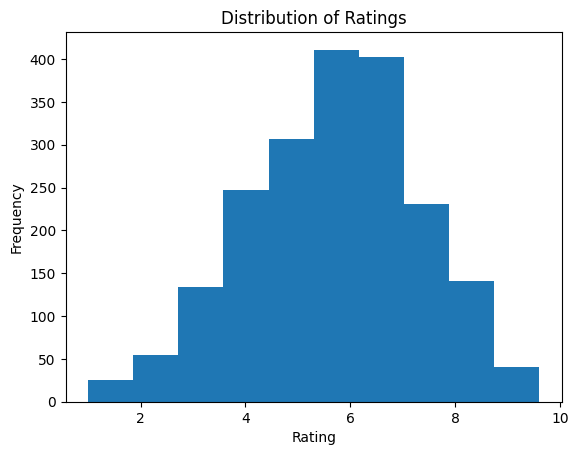

In [250]:
#Rating Histogram

import matplotlib.pyplot as plt

plt.hist(df['rating'])
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

Rating Distribution:
The distribution of ratings appears to be approximately bell shaped distrbution and it has centered around 5-7 range. Most Turkish TV series has recieved moderate ratings while very low and very high ratings are relatively rare. This suggests that the overall quality of the series in the dataset is average, with few extreme cases.

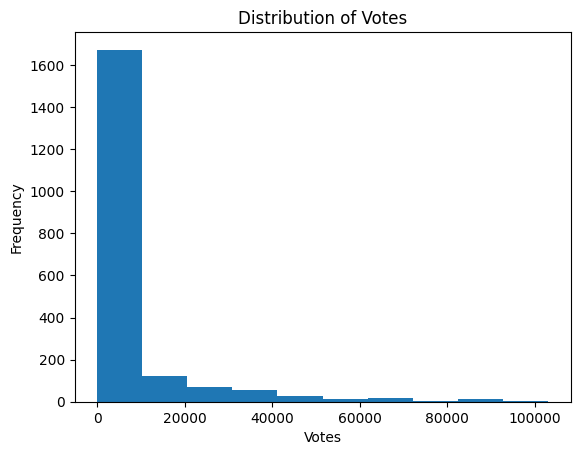

In [251]:
# Votes Histogram

plt.hist(df['votes'])
plt.title('Distribution of Votes')
plt.xlabel('Votes')
plt.ylabel('Frequency')
plt.show()


Votes Distribution:
The distribution of votes is highly right-skewed. Most Turkish TV series receive a relatively low number of votes, while a small number of series receive extremely high vote counts.
This indicates the presence of outliers and suggests that popularity is concentrated in a few high successful series.

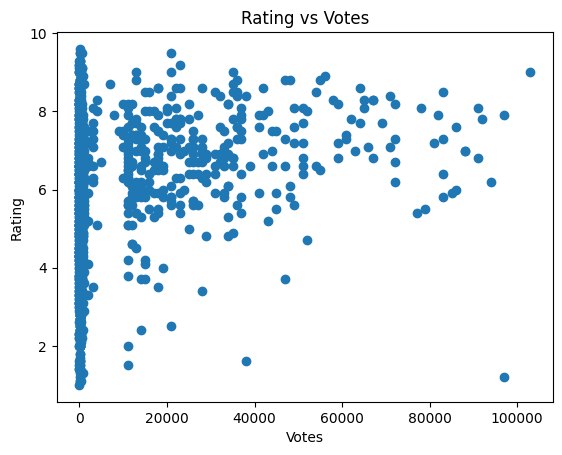

In [252]:
# Relationship analysis between Rating and Votes
plt.scatter(df['votes'], df['rating'])
plt.xlabel('Votes')
plt.ylabel('Rating')
plt.title('Rating vs Votes')
plt.show()

What the scatter plot tells us?

A strong relationship between the number of votes and the rating does not appear. Most of the series are concentrated at low vote counts, but their ratings vary widely. This suggests that havng more votes does not guarantee a higher rating.

However, there are a few series with very high vote counts that may indicate that some popular series tend to have better ratings.So, overall the relationship between votes and rating appear to be weak.

In [253]:
#Correlation Analysis

df['rating'].corr(df['votes'])

np.float64(0.28114430822983255)

Correlation Between Rating and Votes: The correlation between votes and ratings is 0.28, indicating a weak positive relationship. This suggests that TV series with higher vote counts tend to have slightly higher ratings, but the relationship is not strong.

In [254]:
df['genres'].head()

,genres
0,Comedy
1,"Drama,Romance"
2,"Crime,Drama,Mystery"
3,Romance
4,"Action,Crime,Drama"


In [255]:
df['genres'] = df['genres'].str.split(',')
df_exploded = df.explode('genres')

In [256]:
df_exploded['genres'].value_counts()

,count
genres,
Drama,894
Comedy,585
Romance,318
Action,152
Talk-Show,130
Reality-TV,126
Crime,110
Adventure,100
History,92


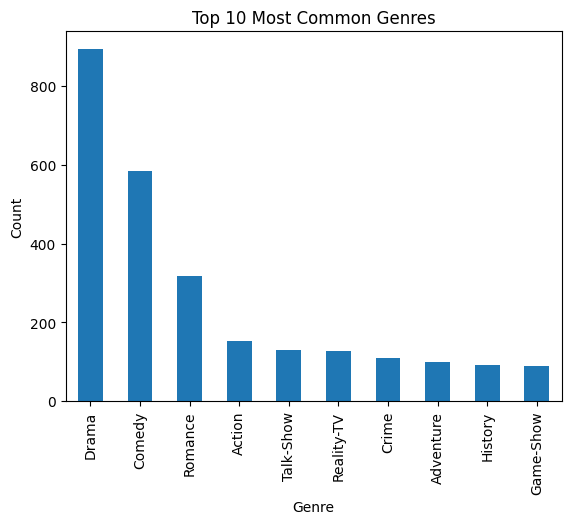

In [257]:
import matplotlib.pyplot as plt

df_exploded['genres'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Most Common Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

Genre Distribution:
The most common genres in the dataset are Drama, Comedy and Romance. Drama appears to be the dominant genre. This indicates that Turkish TV series frequently include dramatic elements, although sometimes it is categorized under multiple genres. Overall; the distribution is imbalanced since it seems that some genres are significantly more popular than others.

In [258]:
#Genre vs Rating

df_exploded.groupby('genres')['rating'].mean().sort_values(ascending=False).head(10)

,rating
genres,
Western,9.300000
Documentary,7.053846
Biography,6.950000
War,6.688235
Animation,6.684211
Talk-Show,6.680769
Mystery,6.589655
Thriller,6.429412
History,6.368478


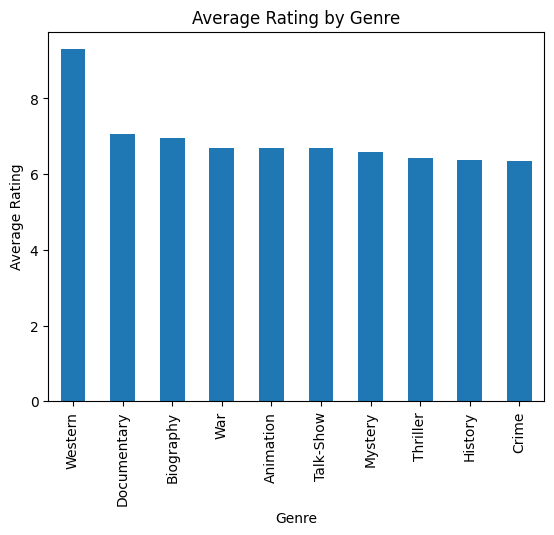

In [259]:
#Genre vs Rating Bar Chart

df_exploded.groupby('genres')['rating'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Average Rating by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.show()


Genre vs Rating:
The average ratings are slightly different across genres. However, the differences are not very large, which means genre does not strongly affect the rating.Overall, the relationship between genre and rating is weak.

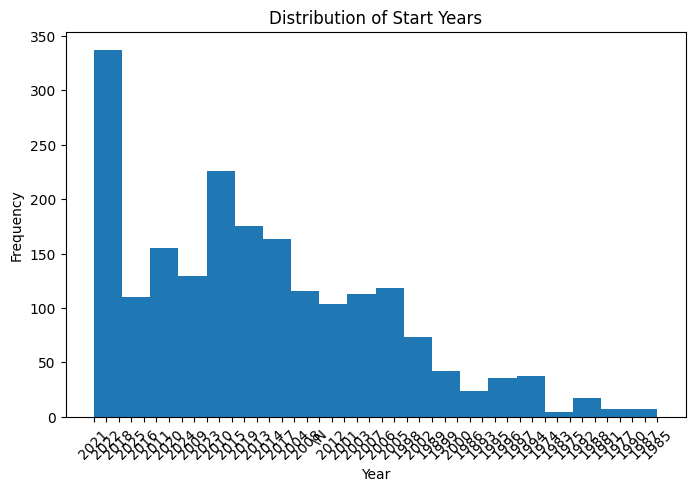

In [260]:
#Distribution of Start Years

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['startYear'], bins=20)
plt.title('Distribution of Start Years')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

Distribution of the start years: Most of the TV series in the dataset were released in recent years.There are fewer series from older years, which shows that the dataset mainly includes newer productions.

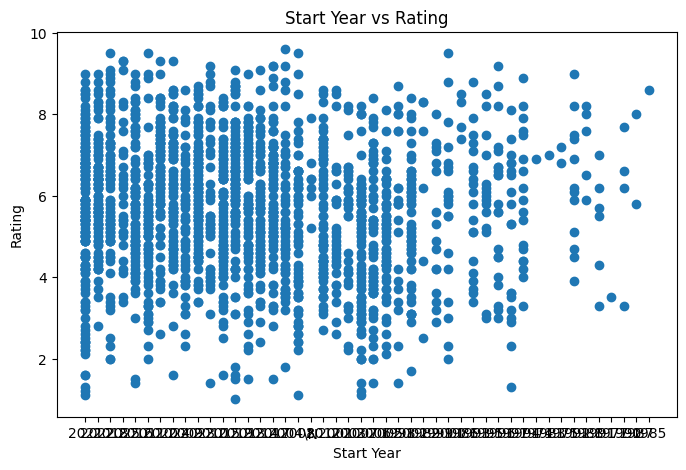

In [261]:
#Year vs Rating

plt.figure(figsize=(8,5))
plt.scatter(df['startYear'], df['rating'])
plt.title('Start Year vs Rating')
plt.xlabel('Start Year')
plt.ylabel('Rating')
plt.show()

Year vs Rating: There is no clear relationship between the start year and the ratings. Ratings seem to be spread randomly across different years. This suggests that the year a series started does not strongly affect its rating.

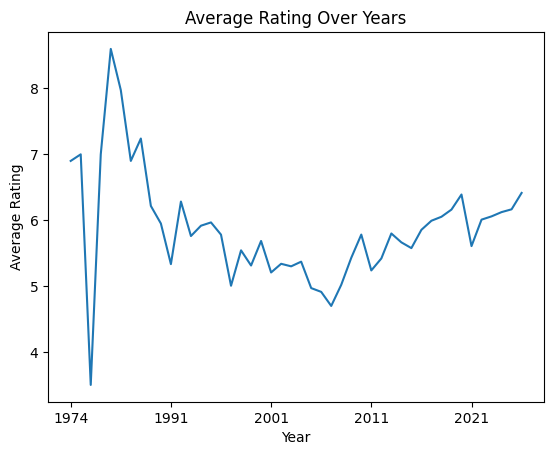

In [262]:
#Year vs Average Rating

df.groupby('startYear')['rating'].mean().plot()
plt.title('Average Rating Over Years')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.show()

Year vs Average Rating: The average rating changes over the years but does not show a strong consistent trend. There are fluctuations, especially in earlier years, which may be due to fewer observations. So, recent years show slighty more stable ratings over the earlier years. Overall, ratings remain relatively stable over time.

EDA SUMMARY:

* In this analysis, several patterns were observed in the dataset. The distribution of ratings shows that most TV series have ratings between
5 and 7,indicating a moderate level of audience evaluation. The votes distribution is highly skewed,meaning that only a small number of series receive very high attention while most have relatively low vote counts.
* The relationship between votes and ratings appears to be weak, suggesting that popularity which is measured by votes does not strongly determine the rating of a series. Similarly,the relationship between start year and rating is not very strong, as ratings are spread across different years without a clear trend.
* Genre analysis shows that Drama, Comedy, and Romance are the most common genres in the dataset. However, there is no strong difference in average ratings across genres, indicating that genre alone does not significantly impact ratings.
* Overall, the dataset suggests that ratings are influenced by multiple factors, and no single variable(votes, genre or year) has a strong direct effect on ratings.





PART 3: HYPOTHESIS TESTING

In this part, we will test whether there are significant relationships between key variables in the dataset.


In [263]:
#Votes vs Rating Correlation
  #H0: There is no relationship between votes and ratings.
  #H1: There is a relationship between votes and ratings.
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['votes'], df['rating'])
print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.2811443082298325
P-value: 1.5907647070603988e-37


The correlation between votes and ratings is approximately 0.28, indicating a weak positive relationship.
Used the Pearson correlation test to examine the relationship between votes and ratings. The p-value is very small (less than 0.05), so we reject the null hypothesis.

This means that there is a statistically significant relationship between votes and ratings, but the strength of the relationship is weak.

In [264]:
df['startYear'] = pd.to_numeric(df['startYear'], errors='coerce')
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

df = df.dropna(subset=['startYear', 'rating'])

In [265]:
#StartYear vs Rating Correlation
  #H0: There is no relationship between start year and ratings.
  #H1: There is a relationship between start year and ratings.

corr, p_value = pearsonr(df['startYear'], df['rating'])
print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.1185306963958094
P-value: 1.173169412805572e-07


The correlation between start year and ratings is approximately 0.12, indicating a very weak positive relationship. Used the Pearson correlation test to examine the relationship between start year and ratings. The p-value is less than 0.05, so we reject the null hypothesis.

This suggests that there is a statistically significant relationship between start year and ratings, but the effect is very weak.

In [266]:
# Genre vs Rating
  #H0: There is no relationship between genre and ratings.
  #H1: There is a relationship between genre and ratings.

from scipy.stats import f_oneway
top_genres = df_exploded['genres'].value_counts().head(3).index
groups = [df_exploded[df_exploded['genres'] == genre]['rating'] for genre in top_genres]
f_stat, p_value = f_oneway(*groups)
print("F-statistic:", f_stat)
print("P-value:", p_value)


F-statistic: 0.014428340045259933
P-value: 0.9856753640226137


Used one-way ANOVA to test whether there are significant differences in ratings across genres. The p-value is much greater than 0.05, so we fail to reject the null hypothesis. This means that there is no statistically significant difference in ratings across genres.

Although some genres (such as Drama) appear more frequently in the dataset, genre does not have a significant effect on ratings.

Overall Conclusion:

* Overall, some variables (such as votes and start year) show statistically significant relationships with ratings, but their effects are weak.
* On the other hand, genre does not have a statistically significant impact on ratings.
* This suggests that ratings are likely influenced by multiple factors, and no single variable strongly determines the ratings.




PART 4: MACHINE LEARNING

In this part, we build a simple machine learning model to predict the rating of TV series. The target variable is the rating, and we use features such as votes, start year, and runtime as predictors. Genre was not included in the model because it is a categorical variable and requires additional preprocessing.

In [267]:
#Data Preparation - Missing values are removed, X and y are defined for the model.
 #Numerical features are used in the model, as machine learning algorithms require numeric input variables.

df['startYear'] = pd.to_numeric(df['startYear'], errors='coerce')
df['runtimeMinutes'] = pd.to_numeric(df['runtimeMinutes'], errors='coerce')
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

df = df.dropna(subset=['votes','startYear','runtimeMinutes','rating'])
X = df[['votes', 'startYear','runtimeMinutes']]
y = df['rating']



In [268]:
#Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [269]:
# Build and train the Linear Regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [270]:
# Make predictions on the test set
y_pred = model.predict(X_test)

y_pred[:5]

array([5.46976404, 5.56749583, 7.0395646 , 6.25631878, 5.54306245])

In [271]:
# Evaluate model performance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)

R2 Score: 0.08529787182460036
MAE: 1.2089936062982627
MSE: 2.2659465315958878


In [272]:
# Random Forest model
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error

print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))

Random Forest R2: 0.2382063662734426
Random Forest MAE: 1.0621888423988843


The Random Forest model performs better than the Linear Regression model. The R² score increased from approximately 0.085 to 0.24, and the MAE decreased slightly.

This shows that the Random Forest model can capture more complex patterns in the data compared to Linear Regression. However, the overall performance is still not very strong.

This indicates that although model choice improves performance, the available features (votes, start year, and runtime) are still not sufficient to accurately predict ratings.

In [273]:
# Feature Importance
import pandas as pd

importance = rf_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(importance_df)

          Feature  Importance
0           votes    0.537278
1       startYear    0.249303
2  runtimeMinutes    0.213420


The feature importance results show which variables have the strongest impact on predicting ratings. This helps us understand which factors are more influential in the model.

Based on the results, votes appear to be the most important predictor, followed by start year and runtime.

OVERALL MACHINE LEARNING:


* Overall, the Random Forest model outperforms the Linear Regression model, indicating that non-linear relationships exist in the data.
* However, both models show relatively low performance, suggesting that the selected features are not sufficient to fully explain the variation in TV series ratings.
* This highlights the complexity of rating behavior and suggests that additional variables would be needed for more accurate predictions.
* This comparison also demonstrates the importance of model selection, as more flexible models like Random Forest can better capture patterns in real-world data.



